In [1]:
import numpy as np 
import tifffile

from matplotlib import pyplot as plt

from napari_mAIcrobe.mAIcrobe.segmentation import unet_segmentation

from skimage.util import random_noise, img_as_ubyte, img_as_float
from skimage.filters import gaussian
from matplotlib.colors import ListedColormap


# 0 -> black, every other integer -> distinct color (up to 65535 labels)
n_labels = 65536
colors = plt.cm.gist_ncar(np.linspace(0, 1, n_labels))
colors[0] = (0, 0, 0, 1)  # background
np.random.default_rng(42).shuffle(colors[1:])  # deterministic shuffle for separation
labeltestcolormap = ListedColormap(colors, name="labeltestcolormap")
plt.colormaps.register(labeltestcolormap, force=True)


img = tifffile.imread('Image 34_Structured Illumination_membrane.tif')
img = img_as_float(img)
mask, labels = unet_segmentation(img, pretrained=False, pretrained_name=None, path2model="../docs/SegmentationModels/UNet4staph_20250922.hdf5", binary_closing=0, binary_dilation=0, binary_fillholes=False)



1/1 [==============================] - 1s 714ms/step


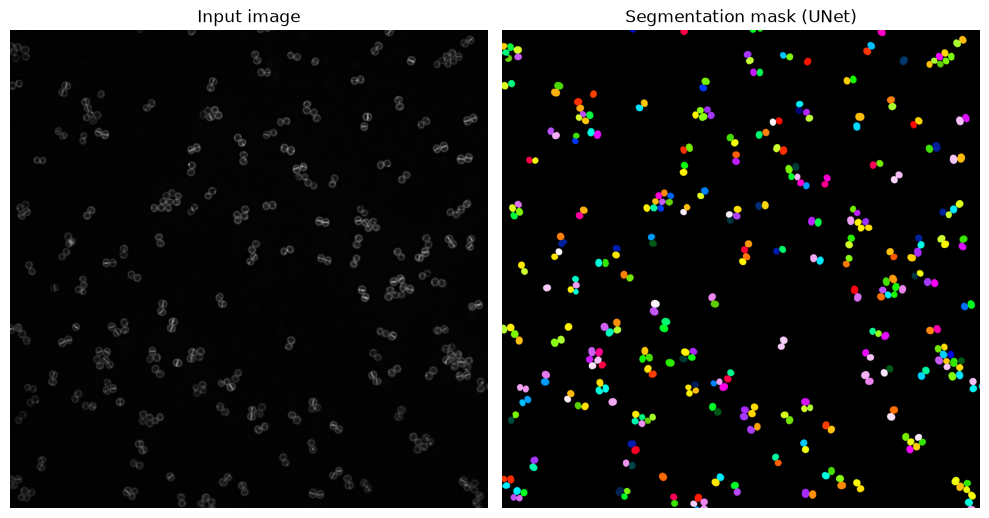

In [2]:
plt.figure(figsize=(10, 7))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Input image')

plt.subplot(1, 2, 2)
plt.imshow(labels, cmap='labeltestcolormap')
plt.title('Segmentation mask (UNet)')
plt.axis('off')

plt.tight_layout()
plt.show()


# I manually selected two regions, one with cells and one with background

In [3]:
img_cells = img[845:1443,1730:2403]
labels_cells = labels[845:1443,1730:2403]
mask_cells = mask[845:1443,1730:2403]

img_bg = img[1231:1504,1279:1579]
labels_bg = labels[1231:1504,1279:1579]
mask_bg = mask[1231:1504,1279:1579]

SNR = np.mean(img_cells-np.min(img_cells))/np.std(img_bg)
print(SNR)

IoU = np.sum(mask_cells&mask_cells)/np.sum(mask_cells|mask_cells)
print(IoU)

17.118948396558174
1.0


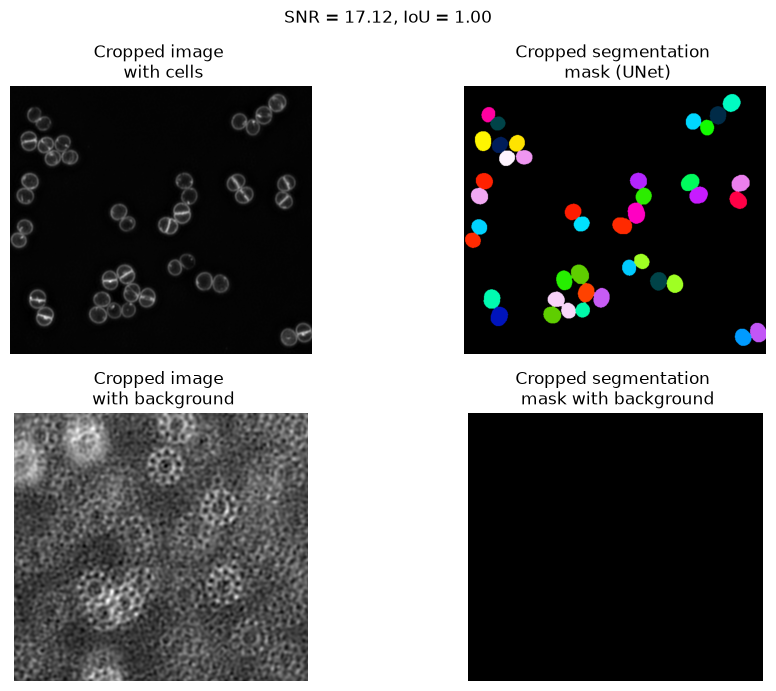

In [4]:
plt.figure(figsize=(10, 7))

plt.subplot(2, 2, 1)
plt.imshow(img_cells, cmap='gray')
plt.axis('off')
plt.title('Cropped image \n with cells')

plt.subplot(2, 2, 2)
plt.imshow(labels_cells, cmap='labeltestcolormap')
plt.title('Cropped segmentation \n mask (UNet)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(img_bg, cmap='gray')
plt.title('Cropped image \n with background')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(labels_bg, cmap='labeltestcolormap')
plt.title('Cropped segmentation \n mask with background')
plt.axis('off')

plt.suptitle('SNR = {:.2f}, IoU = {:.2f}'.format(SNR, IoU))

plt.tight_layout()
plt.show()

 - SIM resolution is around 100-120nm lets assume 100nm for simplicity. 
 
 - Each pixel is ~32nm (0.032um) so resolution should be around 3.125 pixels

 - Assuming a Gaussian PSF with FWHM=3.125, its sigma should be around 1.327 pixels (3.125/2.3548) => variance = 1.327^2 = 1.76

 - So if we want to halve the resolution we want 200nm, which is 6.25 pixels, so sigma = 6.25/2.3548 = 2.65 => variance ~= 7.04

 - Gaussian convolution is additive in variance, to go from 1.76 to 7.04 we need to add 5.28, so sigma = sqrt(5.28) = 2.3 pixels

Blurring flattens BG noise. Lets add gaussian noise to approximately halve our SNR.

$SNR_1 ~= Signal/\sigma(BG)$

$SNR_2 ~= Signal/\sqrt{\sigma(BG)^2 + \sigma(Noise)^2}$

$SNR_1 / SNR_2 = 2$

$ 1/\sigma(BG) = 2 / \sqrt{\sigma(BG)^2 + \sigma(Noise)^2}$

Solving for $\sigma(Noise) = \sqrt{3} * \sigma(BG)$

Since blurred flattend BG noise, we'll use 4 * $\sigma(BG)$ to add noise the "original" noise to the blurred image.

In [5]:
blurred_img = gaussian(img, sigma=2.3, preserve_range=False)
blurred_noised_img = random_noise(blurred_img, mode='gaussian', var=4*np.std(img_bg)**2)
mask_blurred_img, labels_blurred_img = unet_segmentation(blurred_noised_img, pretrained=False, pretrained_name=None, path2model="../docs/SegmentationModels/UNet4staph_20250922.hdf5", binary_closing=0, binary_dilation=0, binary_fillholes=False)

1/1 [==============================] - 1s 742ms/step


In [6]:
img_cells_BLURRED = blurred_noised_img[845:1443,1730:2403]
labels_cells_BLURRED = labels_blurred_img[845:1443,1730:2403]
mask_cells_BLURRED = mask_blurred_img[845:1443,1730:2403]

img_bg_BLURRED = blurred_noised_img[1231:1504,1279:1579]
labels_bg_BLURRED = labels_blurred_img[1231:1504,1279:1579]
mask_bg_BLURRED = mask_blurred_img[1231:1504,1279:1579]

SNR = np.mean(img_cells_BLURRED-np.min(img_cells_BLURRED))/np.std(img_bg_BLURRED)
print(SNR)

IoU = np.sum(mask_cells_BLURRED&mask_cells)/np.sum(mask_cells_BLURRED|mask_cells)
print(IoU)

8.065188208565747
0.9564009997222994


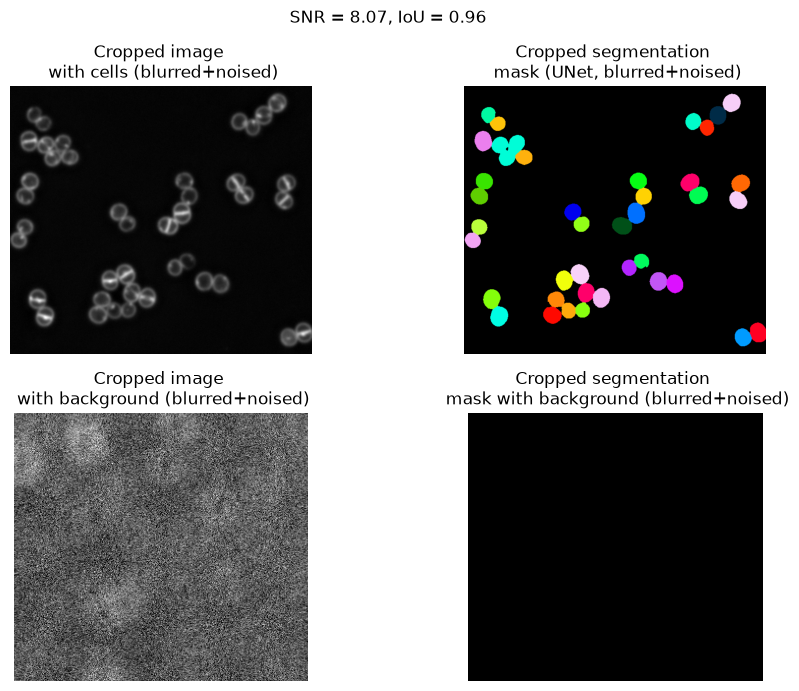

In [7]:
plt.figure(figsize=(10, 7))

plt.subplot(2, 2, 1)
plt.imshow(img_cells_BLURRED, cmap='gray')
plt.axis('off')
plt.title('Cropped image \n with cells (blurred+noised)')

plt.subplot(2, 2, 2)
plt.imshow(labels_cells_BLURRED, cmap='labeltestcolormap')
plt.title('Cropped segmentation \n mask (UNet, blurred+noised)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(img_bg_BLURRED, cmap='gray')
plt.title('Cropped image \n with background (blurred+noised)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(labels_bg_BLURRED, cmap='labeltestcolormap')
plt.title('Cropped segmentation \n mask with background (blurred+noised)')
plt.axis('off')

plt.suptitle('SNR = {:.2f}, IoU = {:.2f}'.format(SNR, IoU))

plt.tight_layout()
plt.show()